# Matrix f and g convex optimization

In this notebook, we will work through the feasibility of updating the deconvolution convex optimization to a multivariate optimization. That is, where f and g were 1-dimensional vectors across time. We are now interested in f and g to contain multiple values across time. This will allow us to deconvolve multiple measures of chromatin in a single optimization run. Such as with chromatin occupancy measures across a genomic window for a gene.

1. A simplified deconvolution of H, f, and g without smoothing (1-dimensional vectors).
2. Add a second dimension to f and g.
3. Add wavelet smoothing to (1).
4. Add wavelet smoothing to (2).
5. Next notebook, for gene chromatin deconvolution

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. In this first example we will create a 1 dimensional deconvolution of f

Text(0.5, 1.0, 'The fit, H*f')

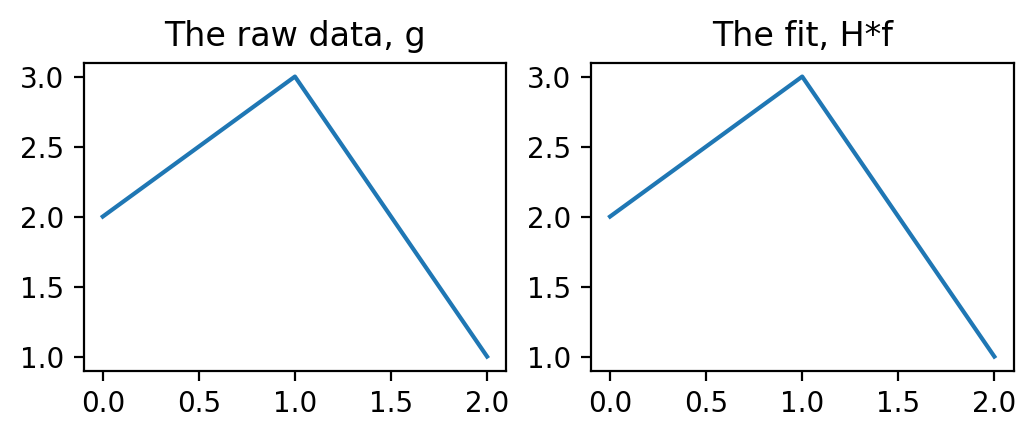

In [3]:
import cvxpy as cp

# Here is the original setup of the basic objective (without wavelet smoothing).

# We have an H matrix (3x3).
# A g vector of values (1x3)

H = np.array([[1, 0, 0], 
              [0, 1, 0],
              [0, 0, 1]])
g = np.array([2, 3, 1])

# And we are trying to determine the best f (3x1) that
# minimizes Hxf / g - 1, (3x3) * (3x1) / (3x1) - 1

f = cp.Variable(H.shape[1])

objective = cp.Minimize(cp.square(cp.pos(cp.norm(H@f/g - 1))))

# Where f is non-negative
constraints = [f >= 0]

# Perform the convex optimization
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL)

# Plot the resulting fit
# Thus, this simple example is resolved.
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.plot(g)
plt.title("The raw data, g")

plt.subplot(1, 2, 2)
plt.plot(np.matmul(H, f.value))
plt.title("The fit, H*f")

## 2. Next, we will add a second dimension to g and f

Text(0.5, 1.0, 'The fit 2, H*f')

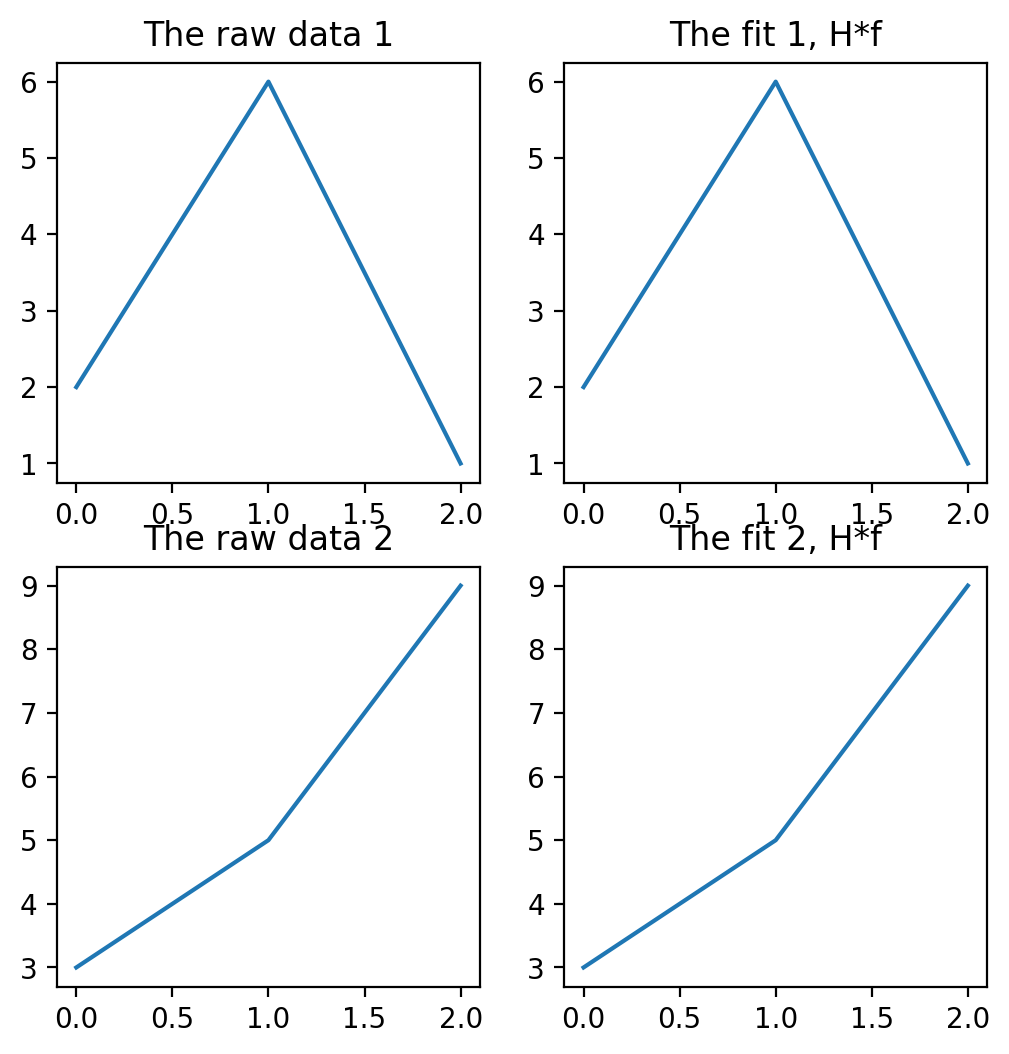

In [4]:
# Next we shall try to add an additional dimension onto f and g.

import cvxpy as cp

# Here is the original setup of the basic objective (without wavelet smoothing).

# We have an H matrix (3x3).
# A g vector of values (1x3)

H = np.array([[1, 0, 0], 
              [0, 1, 0],
              [0, 0, 1]])
g = np.array([[2, 3],
              [6, 5],
              [1, 9]])

# And we are trying to determine the best f (3x1) that
# minimizes Hxf / g - 1, (3x3) * (3x2) / (3x2) - 1

f = cp.Variable((H.shape[1], g.shape[1]))

objective = cp.Minimize(cp.square(cp.pos(cp.norm(H@f/g - 1))))

# Where f is non-negative
constraints = [f >= 0]

# Perform the convex optimization
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL)

# -----------------------
# Plot the result

predicted_G = np.matmul(H, f.value)

# Thus, this simple example is resolved.
plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.plot(predicted_G[:, 0])
plt.title("The raw data 1")
plt.subplot(2, 2, 2)
plt.plot(g[:, 0])
plt.title("The fit 1, H*f")

plt.subplot(2, 2, 3)
plt.plot(predicted_G[:, 1])
plt.title("The raw data 2")

plt.subplot(2, 2, 4)
plt.plot(g[:, 1])
plt.title("The fit 2, H*f")


## 3. Now, we can add the smoothing constraint to the 1 dimensional case

Text(0.5, 1.0, 'The fit, H*f')

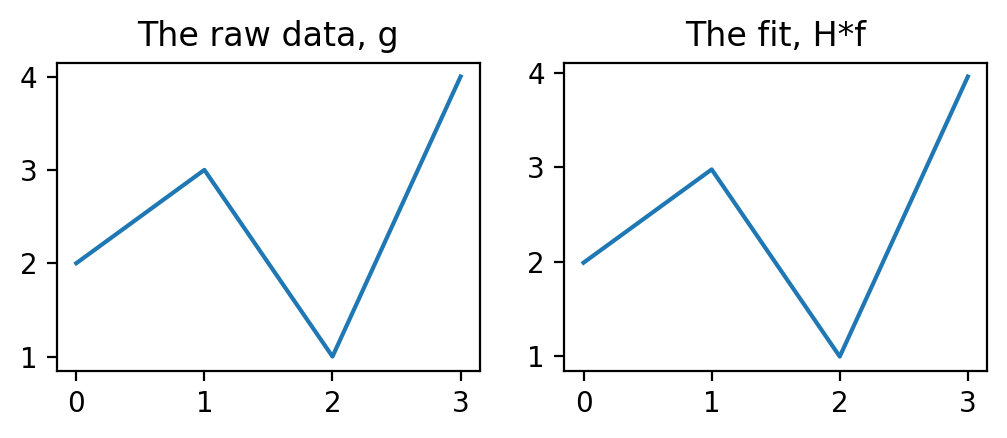

In [6]:
from src.helpers import calcH, createF, get_wavelet_kernel
import cvxpy as cp

# Here is the original setup of the basic objective (without wavelet smoothing).

# We have an H matrix (4x4).
# A g vector of values (4x1)

H = np.array([[1, 0, 0, 0], 
              [0, 1, 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])
g = np.array([2, 3, 1, 4])

# And we are trying to determine the best f (4x1) that
# minimizes Hxf / g - 1, (4x4) * (4x1) / (4x1) - 1

f = cp.Variable(H.shape[1])
gamma = 0.1

# We will imgine that the subset of the "initial" and "top" branches will be the first two indices of the f vector
f_it = [0, 1]

# And the bottom branch will be the last two indices
f_b = [2, 3]

# Then we will make wavelets of the appropriate size
W1 = get_wavelet_kernel(len(f_it))
W2 = get_wavelet_kernel(len(f_b))

# Add the wavelet smoothing constraint to the convex optimization
objective = cp.Minimize(cp.square(cp.pos(cp.norm(H@f/g - 1))) +
                       gamma * (cp.norm(W1@f[f_it], 1) +
                                cp.norm(W2@f[f_b], 1))
                       )

# Where f is non-negative
constraints = [f >= 0]

# Perform the convex optimization
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL)

# Plot the resulting fit
# Thus, this simple example is resolved.
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.plot(g)
plt.title("The raw data, g")

plt.subplot(1, 2, 2)
plt.plot(np.matmul(H, f.value))
plt.title("The fit, H*f")


## 4. Now, we can see if we can add in the smoothing to the 2 dimensional case

Text(0.5, 1.0, 'The fit 2, H*f')

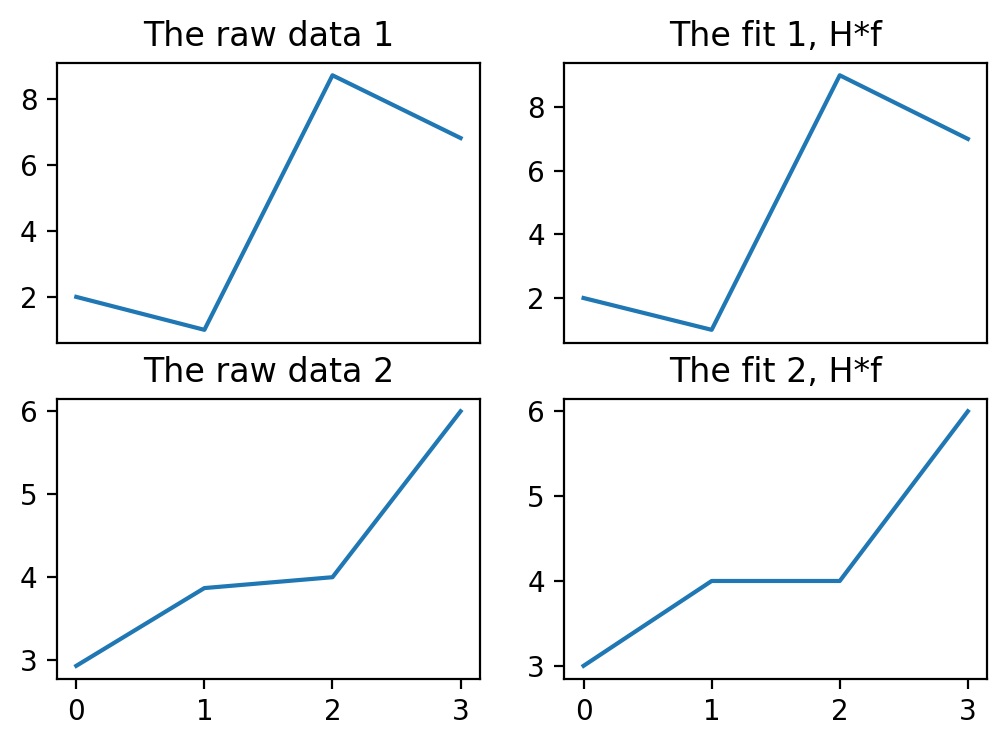

In [10]:
# Next we shall try to add an additional dimension onto f and g.

import cvxpy as cp

# We have an H matrix (4x4).
# A g vector of values (4x2)

H = np.array([[1, 0, 0, 0], 
              [0, 1, 0, 0],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])
g = np.array([[2, 3],
              [1, 4],
              [9, 4],
              [7, 6]])

# And we are trying to determine the best f (4x2) that
# minimizes Hxf / g - 1, (4x4) * (4x2) / (4x2) - 1
f = cp.Variable((H.shape[1], g.shape[1]))

# We will imgine that the subset of the "initial" and "top" branches will be the first two 
# indices of the f vector
f_it = [0, 1]

# And the bottom branch will be the last two indices
f_b = [2, 3]

# Then we will make wavelets of the appropriate size
W1 = get_wavelet_kernel(len(f_it))
W2 = get_wavelet_kernel(len(f_b))

# Add the wavelet smoothing constraint to the convex optimization
objective = cp.Minimize(cp.square(cp.pos(cp.norm(H@f/g - 1))) +
                        gamma * (cp.norm(W1@f[f_it], 1) +
                                 cp.norm(W2@f[f_b], 1)))

# Where f is non-negative
constraints = [f >= 0]

# Perform the convex optimization
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL)

# -----------------------

# Plot the result
predicted_G = np.matmul(H, f.value)

# Thus, this simple example is resolved.
plt.figure(figsize=(6, 4))
plt.subplot(2, 2, 1)
plt.plot(predicted_G[:, 0])
plt.xticks([])
plt.title("The raw data 1")
plt.subplot(2, 2, 2)
plt.plot(g[:, 0])
plt.xticks([])
plt.title("The fit 1, H*f")

plt.subplot(2, 2, 3)
plt.plot(predicted_G[:, 1])
plt.title("The raw data 2")

plt.subplot(2, 2, 4)
plt.plot(g[:, 1])
plt.title("The fit 2, H*f")


In [ ]:
# Notes on the thought process of translating the smoothing constraint to an additional dimension

# If f is a matrix of size 4x2

# Then, indexing for the wavelet, should look something like:
# f[f_it], 2x2 submatrices.
#
# So the question, is how does the wavelet handle a matrix input, otherwise, we can just construct a matrix out of vector copies
# of the 1 directional wavelet
#

# So the wavelet actually returns a 2 dimensional matrix from a 1 dimension input.
# So what will this look like if I want to input a 2 dimensional input?

# Let's look at the smoothing constraint.
#
#   W1 * f[f_it]  ----- is -------- (2x2) * (2x1) = (2x1)
#
# So maybe it's okay to remain two dimensions because it is multiplied against the rows of f. In the two dimenional case:
#
#   W1 * f[f_it]  ----- is -------- (2x2) * (2x2) = (2x2)
#
f.shape